In [ ]:
library(readxl)
library(dplyr)
library(ggplot2)

data <- read_excel("data_manip_densite_tube.xlsx",
                   sheet = "density_data")

head(data)
str(data)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




treatment,ID_tube,start_xp,count_date,day,replicate,dead_smurf,accidental_death,total_smurf,alive_smurf,passage smurf,proportion_passage_smurf,smurf_proportion,dead_proportion,survival_proportion,nb_death,comment,alive_female,nbr_female_in_tube,nbr_initial
<dbl>,<chr>,<dttm>,<dttm>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
20,20A,2026-04-21,2026-04-24,3,A,0,0,0,0,0,0,0,0.000,1.000,0,NA,20,20,20
20,20B,2026-04-21,2026-04-24,3,B,0,0,0,0,0,0,0,0.000,1.000,0,NA,20,20,20
20,20C,2026-04-21,2026-04-24,3,C,0,0,0,0,0,0,0,0.000,1.000,0,NA,20,20,20
20,20D,2026-04-21,2026-04-24,3,D,0,0,0,0,0,0,0,0.000,1.000,0,NA,20,20,20
20,20E,2026-04-21,2026-04-24,3,E,0,0,0,0,0,0,0,0.000,1.000,0,NA,20,20,20
40,40A,2026-04-21,2026-04-24,3,A,0,1,0,0,0,0,0,0.025,0.975,1,NA,39,40,40


tibble [360 × 20] (S3: tbl_df/tbl/data.frame)
 $ treatment               : num [1:360] 20 20 20 20 20 40 40 40 40 40 ...
 $ ID_tube                 : chr [1:360] "20A" "20B" "20C" "20D" ...
 $ start_xp                : POSIXct[1:360], format: "2026-04-21" "2026-04-21" ...
 $ count_date              : POSIXct[1:360], format: "2026-04-24" "2026-04-24" ...
 $ day                     : num [1:360] 3 3 3 3 3 3 3 3 3 3 ...
 $ replicate               : chr [1:360] "A" "B" "C" "D" ...
 $ dead_smurf              : num [1:360] 0 0 0 0 0 0 0 0 0 0 ...
 $ accidental_death        : num [1:360] 0 0 0 0 0 1 0 0 0 0 ...
 $ total_smurf             : num [1:360] 0 0 0 0 0 0 0 0 0 0 ...
 $ alive_smurf             : num [1:360] 0 0 0 0 0 0 0 0 0 0 ...
 $ passage smurf           : num [1:360] 0 0 0 0 0 0 0 0 0 0 ...
 $ proportion_passage_smurf: num [1:360] 0 0 0 0 0 0 0 0 0 0 ...
 $ smurf_proportion        : num [1:360] 0 0 0 0 0 0 0 0 0 0 ...
 $ dead_proportion         : num [1:360] 0 0 0 0 0 0.025 0 0 0 

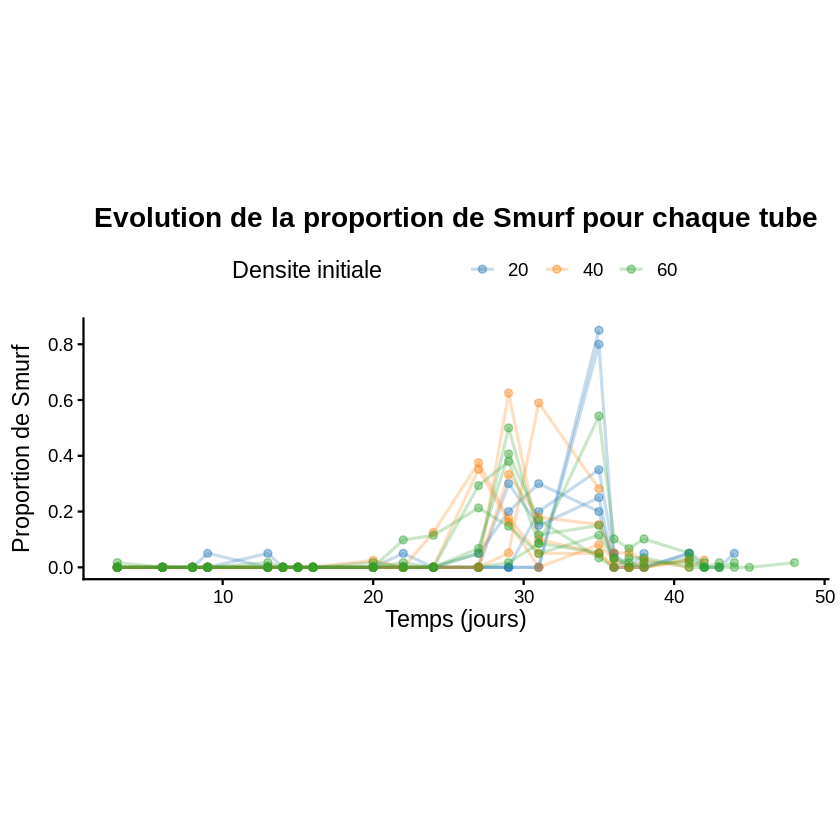

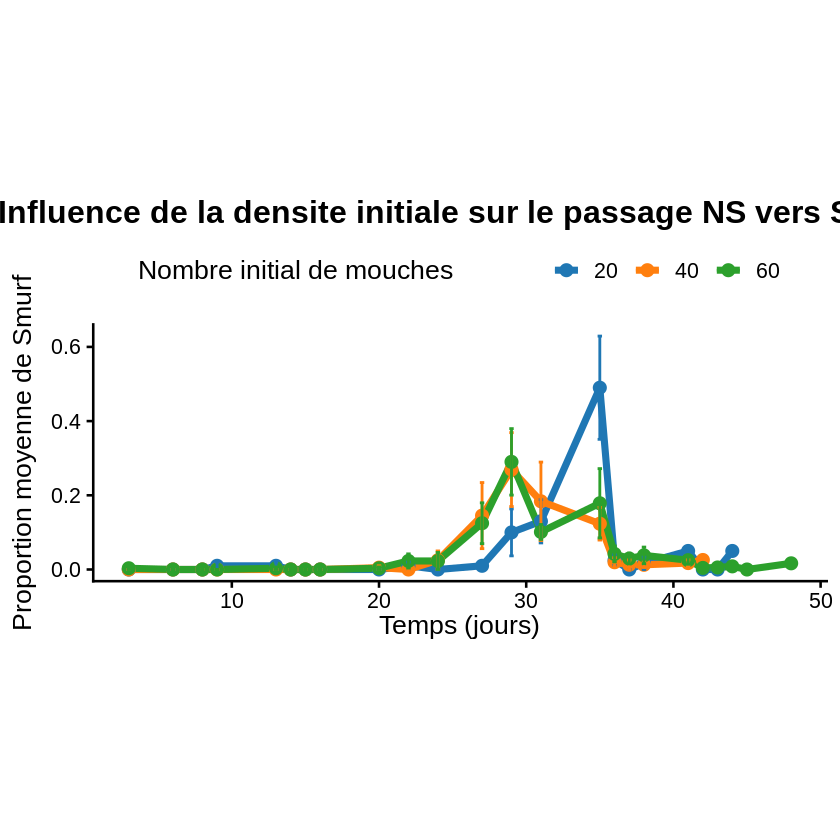

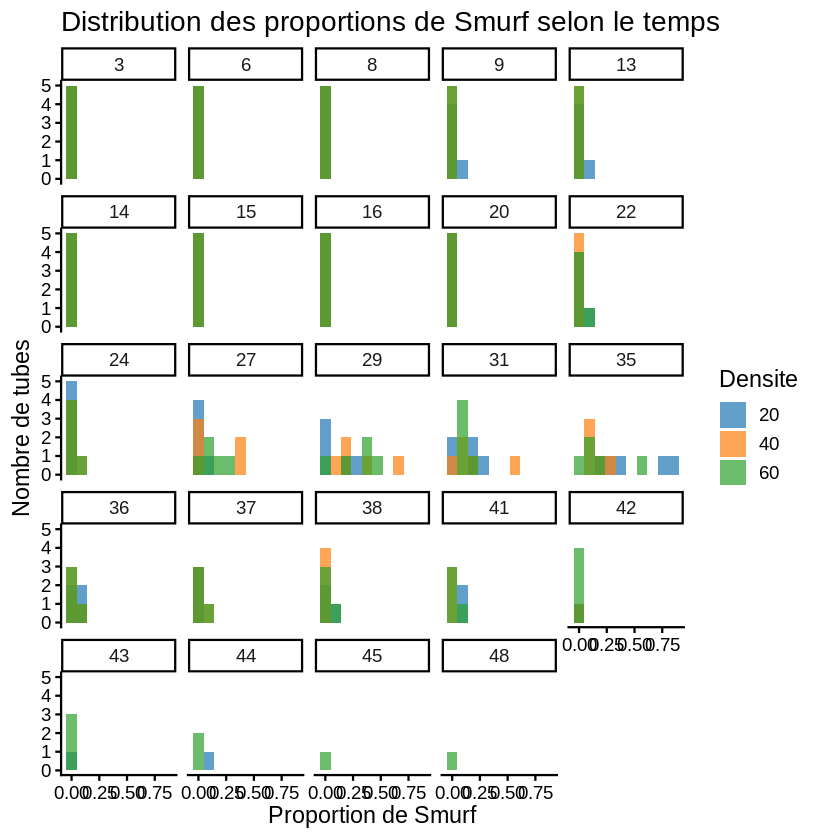

In [ ]:
############################################################
# 1. CREATION DE LA VARIABLE D'INTERET
############################################################
# Passage NS -> Smurf
# Une mouche reste comptabilisee comme ayant ete Smurf
# meme si elle meurt ensuite

data <- data %>%
  mutate(
    proportion_smurf =
      total_smurf / nbr_initial
  )


############################################################
# 2. NETTOYAGE DES DONNEES POUR LES GRAPHIQUES
############################################################

data_plot <- data %>%
  filter(
    !is.na(day),
    !is.na(total_smurf),
    !is.na(nbr_initial),
    nbr_initial > 0
  )


############################################################
# 3. COULEURS DES DENSITES
############################################################

couleurs_densite <- c(
  "20" = "#1f77b4",
  "40" = "#ff7f0e",
  "60" = "#2ca02c"
)



############################################################
# 4. GRAPH DES 15 TUBES INDIVIDUELS
############################################################

graph_individuel <- ggplot(
  data_plot,
  aes(
    x = day,
    y = proportion_smurf,
    group = ID_tube,
    color = factor(treatment)
  )
) +

  geom_line(
    alpha = 0.25,
    linewidth = 0.9
  ) +

  geom_point(
    alpha = 0.4,
    size = 1.8
  ) +

  scale_color_manual(
    values = couleurs_densite
  ) +

  labs(
    title =
      "Evolution de la proportion de Smurf pour chaque tube",

    x =
      "Temps (jours)",

    y =
      "Proportion de Smurf",

    color =
      "Densite initiale"
  ) +

  theme_classic(base_size = 14) +

  theme(
    aspect.ratio = 0.35,
    legend.position = "top",
    plot.title =
      element_text(
        hjust = 0.5,
        face = "bold"
      )
  )


graph_individuel



############################################################
# 5. MOYENNE PAR DENSITE
############################################################


data_mean <- data_plot %>%

  group_by(
    treatment,
    day
  ) %>%

  summarise(

    mean_smurf =
      mean(
        proportion_smurf,
        na.rm = TRUE
      ),

    sd_smurf =
      sd(
        proportion_smurf,
        na.rm = TRUE
      ),

    n =
      n(),

    se_smurf =
      sd_smurf / sqrt(n),

    .groups = "drop"

  )



############################################################
# 6. GRAPH PRINCIPAL : EFFET DE LA DENSITE
############################################################


graph_densite <- ggplot(
  data_mean,
  aes(
    x = day,
    y = mean_smurf,
    color = factor(treatment)
  )
) +

  geom_line(
    linewidth = 2
  ) +

  geom_point(
    size = 3
  ) +

  geom_errorbar(
    aes(
      ymin =
        mean_smurf - se_smurf,

      ymax =
        mean_smurf + se_smurf
    ),

    width = 0.3,
    linewidth = 0.8
  ) +

  scale_color_manual(
    values = couleurs_densite
  ) +

  labs(
    title =
      "Influence de la densite initiale sur le passage NS vers Smurf",

    x =
      "Temps (jours)",

    y =
      "Proportion moyenne de Smurf",

    color =
      "Nombre initial de mouches"
  ) +

  theme_classic(base_size = 16) +

  theme(
    aspect.ratio = 0.35,

    legend.position = "top",

    plot.title =
      element_text(
        hjust = 0.5,
        face = "bold"
      )
  )


graph_densite



############################################################
# 7. HISTOGRAMMES PAR JOUR
############################################################


graph_hist <- ggplot(
  data_plot,
  aes(
    x = proportion_smurf,
    fill = factor(treatment)
  )
) +

  geom_histogram(
    bins = 10,
    alpha = 0.7,
    position = "identity"
  ) +

  facet_wrap(
    ~day
  ) +

  scale_fill_manual(
    values = couleurs_densite
  ) +

  labs(
    title =
      "Distribution des proportions de Smurf selon le temps",

    x =
      "Proportion de Smurf",

    y =
      "Nombre de tubes",

    fill =
      "Densite"
  ) +

  theme_classic(base_size = 14)



graph_hist



############################################################
# 8. EXPORT DES GRAPHIQUES EN GRAND FORMAT
############################################################


ggsave(
  "courbes_tubes_smurf.png",
  graph_individuel,
  width = 14,
  height = 4,
  dpi = 300
)


ggsave(
  "effet_densite_smurf.png",
  graph_densite,
  width = 14,
  height = 4,
  dpi = 300
)

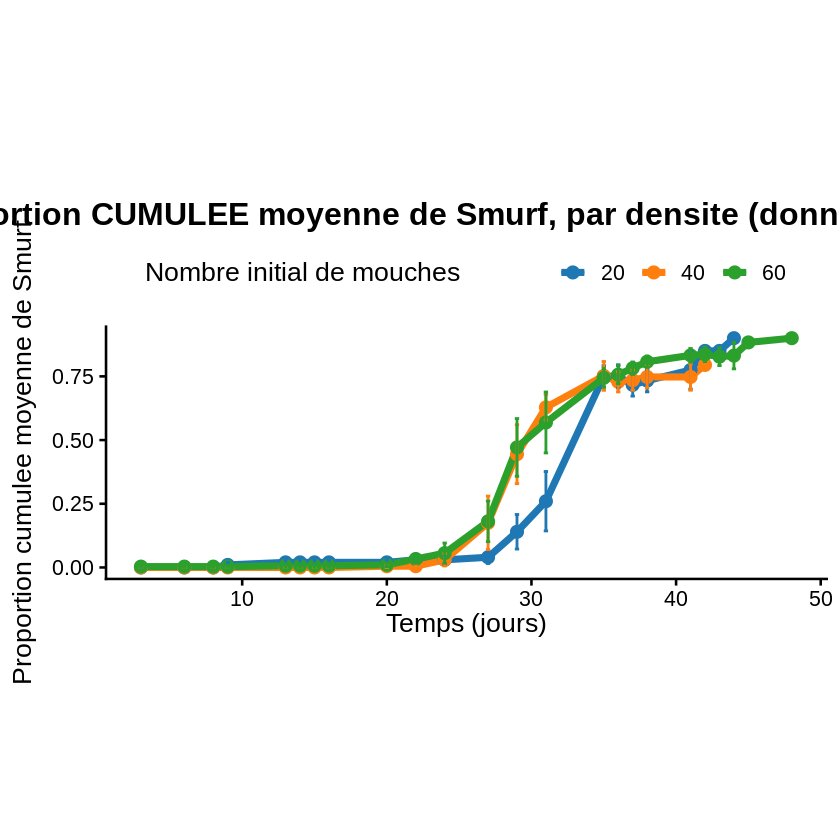

In [ ]:


############################################################
# 1. CREATION DE LA VARIABLE D'INTERET
############################################################
# Passage NS -> Smurf
# Une mouche reste comptabilisee comme ayant ete Smurf
# meme si elle meurt ensuite

data <- data %>%
  mutate(
    proportion_smurf =
      total_smurf / nbr_initial
  )


############################################################
# 1. VARIABLE CUMULEE
############################################################

data <- data %>%
  arrange(ID_tube, day) %>%
  group_by(ID_tube) %>%
  mutate(
    cum_smurf = cumsum(replace(passage_smurf, is.na(passage_smurf), 0)),
    proportion_smurf_cumulee = cum_smurf / nbr_initial
  ) %>%
  ungroup()


############################################################
# 2. NETTOYAGE DES DONNEES POUR LES GRAPHIQUES
############################################################

data_plot <- data %>%
  filter(
    !is.na(day),
    !is.na(total_smurf),
    !is.na(nbr_initial),
    nbr_initial > 0
  )


############################################################
# 3. COULEURS DES DENSITES
############################################################

couleurs_densite <- c(
  "20" = "#1f77b4",
  "40" = "#ff7f0e",
  "60" = "#2ca02c"
)


############################################################
# 5. MOYENNE CUMULEE PAR DENSITE
############################################################

data_mean_cumulee <- data_plot %>%
  group_by(
    treatment,
    day
  ) %>%
  summarise(
    mean_smurf_cumule =
      mean(proportion_smurf_cumulee, na.rm = TRUE),
    sd_smurf_cumule =
      sd(proportion_smurf_cumulee, na.rm = TRUE),
    n = n(),
    se_smurf_cumule = sd_smurf_cumule / sqrt(n),
    .groups = "drop"
  )


############################################################
# 6. GRAPH : PROPORTION SMURF CUMULEE MOYENNE PAR DENSITE
#
############################################################

graph_densite_cumulee <- ggplot(
  data_mean_cumulee,
  aes(
    x = day,
    y = mean_smurf_cumule,
    color = factor(treatment)
  )
) +

  geom_line(linewidth = 2) +
  geom_point(size = 3) +

  geom_errorbar(
    aes(
      ymin = mean_smurf_cumule - se_smurf_cumule,
      ymax = mean_smurf_cumule + se_smurf_cumule
    ),
    width = 0.3,
    linewidth = 0.8
  ) +

  scale_color_manual(values = couleurs_densite) +

  labs(
    title = "Proportion CUMULEE moyenne de Smurf, par densite (donnees reelles)",
    x = "Temps (jours)",
    y = "Proportion cumulee moyenne de Smurf",
    color = "Nombre initial de mouches"
  ) +

  theme_classic(base_size = 16) +

  theme(
    aspect.ratio = 0.35,
    legend.position = "top",
    plot.title = element_text(hjust = 0.5, face = "bold")
  )

graph_densite_cumulee

ggsave(
  "effet_densite_smurf_cumulee.png",
  graph_densite_cumulee,
  width = 14,
  height = 4,
  dpi = 300
)

ID_tube,day,ks
<chr>,<dbl>,<dbl>
20A,3,NA
20B,3,NA
20C,3,NA
20D,3,NA
20E,3,NA
40A,3,NA
40B,3,NA
40C,3,NA
40D,3,NA


`geom_smooth()` using formula = 'y ~ x'


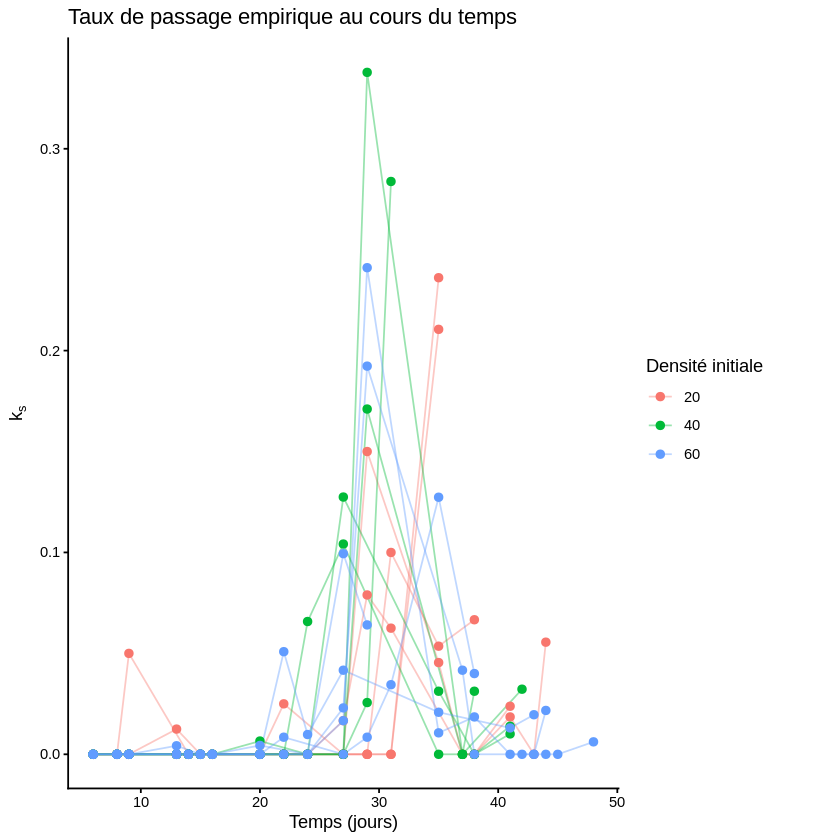

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 11 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`).”


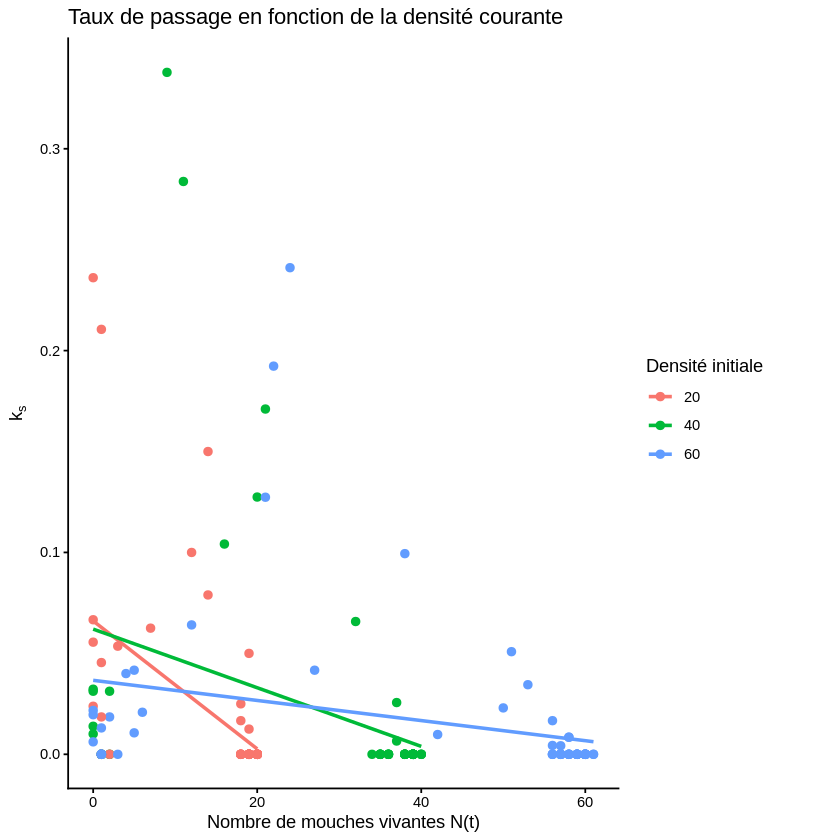

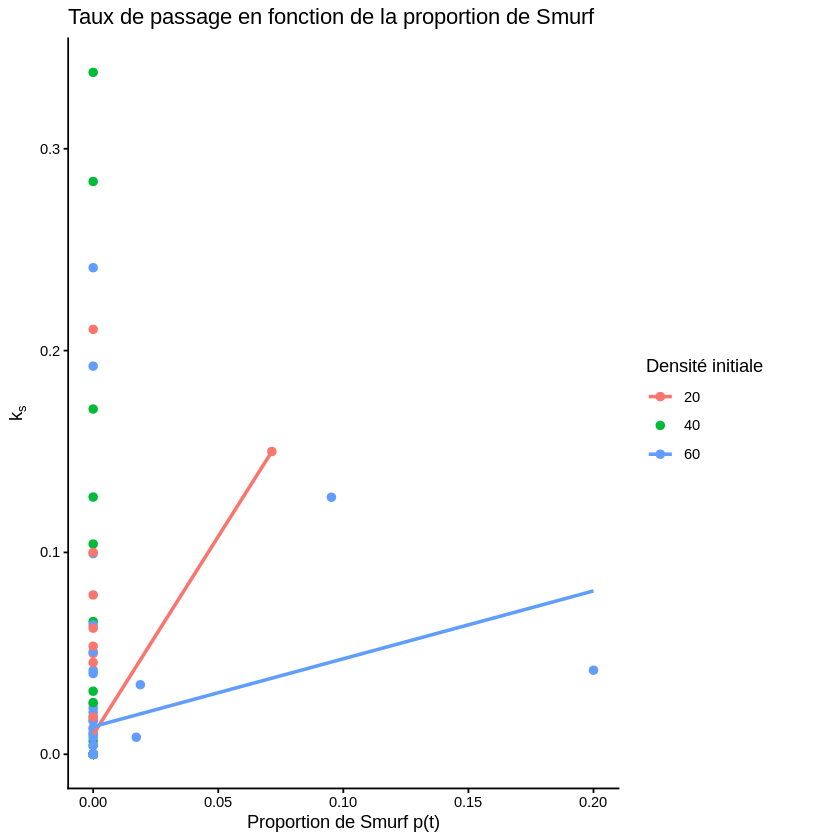

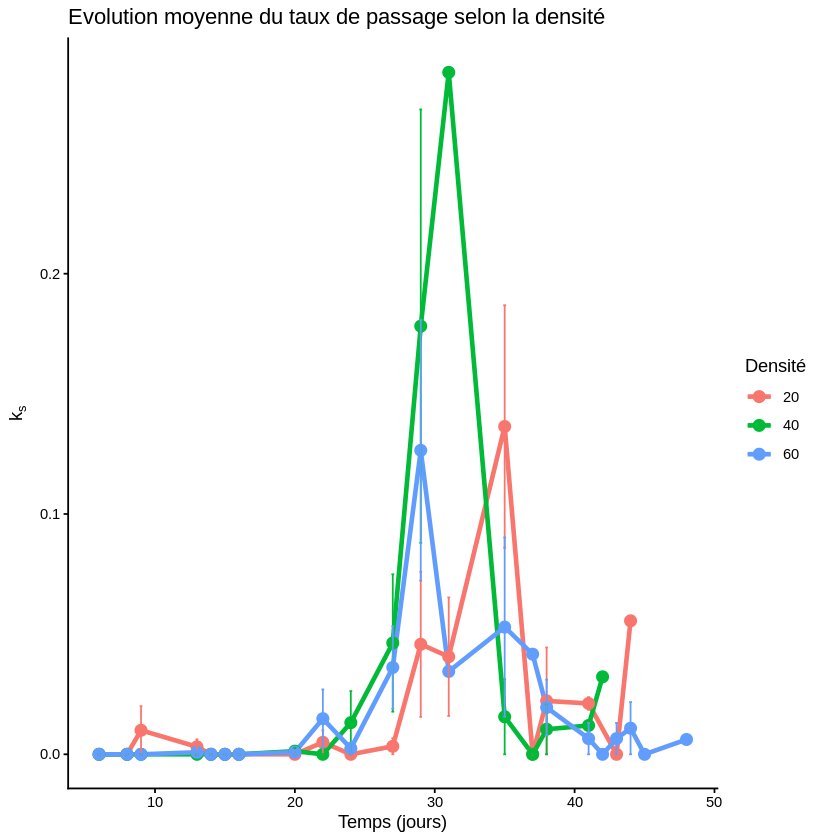

In [ ]:
############################################################
# 1. TRI DES DONNEES
############################################################

data <- data %>%
  arrange(ID_tube, day)


############################################################
# 2. CALCUL DES VARIABLES BIOLOGIQUES
############################################################

data_ks <- data %>%
  group_by(ID_tube) %>%
  arrange(day) %>%
  mutate(

    # Nombre total de mouches ayant effectué NS -> Smurf
    # (Smurf vivantes + Smurf mortes)
    S_cumul = alive_smurf + dead_smurf,


    # Morts accidentelles cumulées
    accidental_cumul = cumsum(accidental_death),


    # Nombre de mouches encore en état NS
    # pouvant encore devenir Smurf
    NS = nbr_initial - S_cumul - accidental_cumul,


    # Nouveaux passages NS -> Smurf pendant l'intervalle
    deltaS = S_cumul - lag(S_cumul),


    # Durée de l'intervalle
    deltaT = day - lag(day),


    # Nombre de NS au début de l'intervalle
    NS_previous = lag(NS),


    # Taux de passage empirique
    ks = deltaS / (NS_previous * deltaT),


    # Densité courante N(t)
    N = alive_female,


    # Proportion de Smurf parmi les vivantes
    p = alive_smurf / alive_female

  ) %>%
  ungroup()

data_ks %>%
  select(ID_tube, day, ks)

############################################################
# 3. NETTOYAGE DES VALEURS IMPOSSIBLES
############################################################

data_ks <- data_ks %>%
  filter(
    !is.na(ks),
    is.finite(ks),
    deltaT > 0,
    NS_previous > 0,
    ks >= 0
  )



############################################################
# 4. EVOLUTION DU TAUX DE PASSAGE DANS LE TEMPS
############################################################

ggplot(data_ks,
       aes(x = day,
           y = ks,
           colour = factor(treatment),
           group = ID_tube)) +

  geom_line(alpha = 0.4) +

  geom_point(size = 2) +

  theme_classic() +

  labs(
    title = "Taux de passage empirique au cours du temps",
    x = "Temps (jours)",
    y = expression(k[s]),
    colour = "Densité initiale"
  )



############################################################
# 5. TAUX DE PASSAGE EN FONCTION DE LA DENSITE COURANTE
############################################################

ggplot(data_ks,
       aes(x = N,
           y = ks,
           colour = factor(treatment))) +

  geom_point(size = 2) +

  geom_smooth(method = "lm",
              se = FALSE,
              linewidth = 1) +

  theme_classic() +

  labs(
    title = "Taux de passage en fonction de la densité courante",
    x = "Nombre de mouches vivantes N(t)",
    y = expression(k[s]),
    colour = "Densité initiale"
  )



############################################################
# 6. TAUX DE PASSAGE EN FONCTION DE LA PROPORTION DE SMURF
############################################################

ggplot(data_ks,
       aes(x = p,
           y = ks,
           colour = factor(treatment))) +

  geom_point(size = 2) +

  geom_smooth(method = "lm",
              se = FALSE,
              linewidth = 1) +

  theme_classic() +

  labs(
    title = "Taux de passage en fonction de la proportion de Smurf",
    x = "Proportion de Smurf p(t)",
    y = expression(k[s]),
    colour = "Densité initiale"
  )



############################################################
# 7. MOYENNE DU TAUX DE PASSAGE PAR DENSITE
############################################################

ks_mean <- data_ks %>%
  group_by(treatment, day) %>%
  summarise(
    ks_moyen = mean(ks, na.rm = TRUE),
    sd = sd(ks, na.rm = TRUE),
    n = n(),
    se = sd / sqrt(n),
    .groups = "drop"
  )


############################################################
# 8. EVOLUTION MOYENNE DU TAUX DE PASSAGE
############################################################

ggplot(ks_mean,
       aes(x = day,
           y = ks_moyen,
           colour = factor(treatment))) +

  geom_line(linewidth = 1.3) +

  geom_point(size = 3) +

  geom_errorbar(aes(ymin = ks_moyen - se,
                    ymax = ks_moyen + se),
                width = 0.2) +

  theme_classic() +

  labs(
    title = "Evolution moyenne du taux de passage selon la densité",
    x = "Temps (jours)",
    y = expression(k[s]),
    colour = "Densité"
  )

**Simulation population**

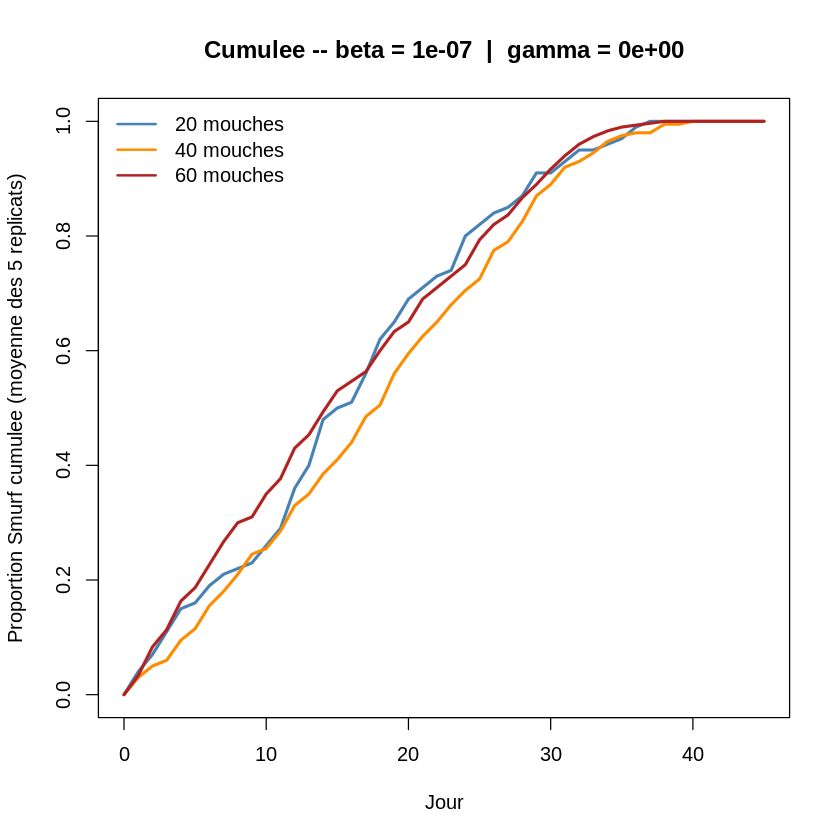

Graphiques enregistres :
 - ./simulation_beta_1e_07_cumulee.png 
 - ./simulation_beta_1e_07_instantanee.png 


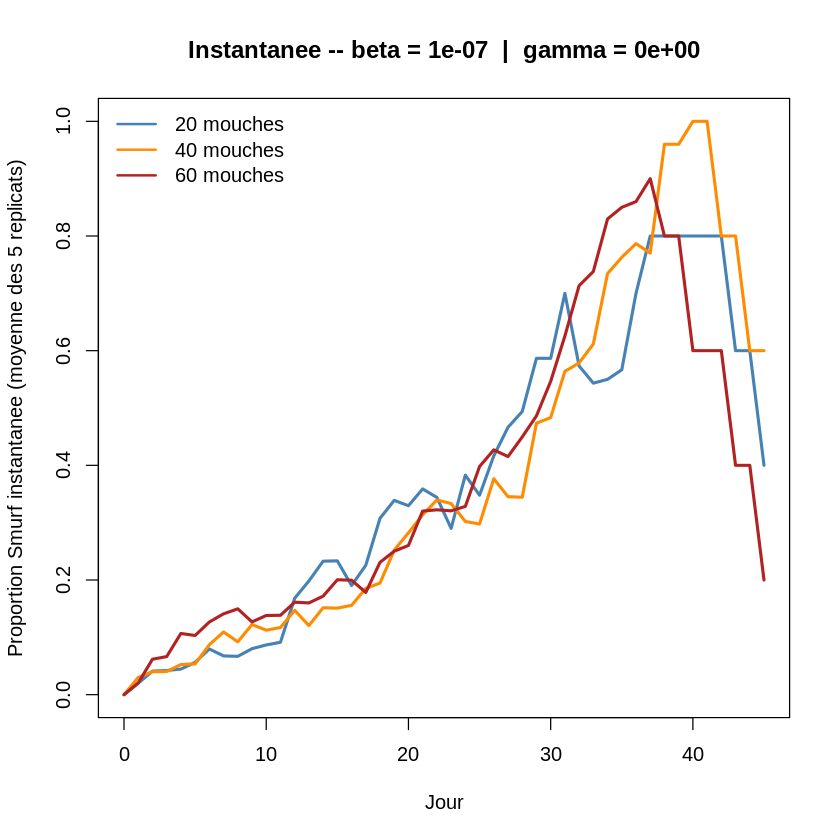

In [ ]:
#################################################################
# 1. SIMULATEUR
#################################################################

simuler_tube_contagion <- function(count_days, N0, accidental_per_period,
                                    F, G, H,
                                    beta = 0, gamma = 0,
                                    K1, K2, D,
                                    n_substeps = 20){

  n_dates <- length(count_days)
  status <- rep("NS", N0)
  age <- rep(0, N0)
  age_smurf <- rep(NA, N0)

  out_dead_smurf   <- numeric(n_dates)
  out_alive_smurf  <- numeric(n_dates)
  out_total_smurf  <- numeric(n_dates)
  out_passage      <- numeric(n_dates)
  out_alive_female <- numeric(n_dates)

  out_alive_female[1] <- sum(status != "DeadSmurf" & status != "DeadAccidental")
  out_alive_smurf[1]  <- sum(status == "Smurf")
  n_dead_smurf_cumul_prec <- 0

  for(i in 2:n_dates){
    t_start <- count_days[i-1]; t_end <- count_days[i]
    dt_total <- t_end - t_start; dt <- dt_total / n_substeps

    # N(t) : densite COURANTE = nombre de mouches encore vivantes au comptage precedent
    n_courant <- sum(status == "NS" | status == "Smurf")

    for(s in 1:n_substeps){

    # Temps courant en jours
    t_now <- t_start + (s-1)*dt

    # Conversion en heures (les paramètres F,G,H,K1,K2,D sont en h^-1)
    t_now_h <- 24 * t_now
    dt_h <- 24 * dt

    idx_ns <- which(status == "NS")
      if(length(idx_ns) > 0){

  # Taux de passage (temps exprimé en heures)
  ks <- F + G*exp(H*t_now_h) +
        beta*N0 +
        gamma*n_courant

  ks <- pmax(ks, 0)

  # Probabilité sur le pas de temps
  prob_transition <- 1 - exp(-ks * dt_h)

  transitions <- runif(length(idx_ns)) < prob_transition

  newly_smurf <- idx_ns[transitions]

  if(length(newly_smurf) > 0){
    status[newly_smurf] <- "Smurf"
    age_smurf[newly_smurf] <- 0
  }

}
      idx_s <- which(status == "Smurf")

if(length(idx_s) > 0){

  # Age Smurf exprimé en heures
  age_smurf_h <- 24 * age_smurf[idx_s]

  # Taux de mortalité
  kd <- K1 + K2*exp(-D*age_smurf_h)

  kd <- pmax(kd, 0)

  # Probabilité de mourir pendant le sous-pas
  prob_death <- 1 - exp(-kd * dt_h)

  deaths <- runif(length(idx_s)) < prob_death

  if(any(deaths))
    status[idx_s[deaths]] <- "DeadSmurf"

}
      age <- age + dt
      idx_s_alive <- which(status == "Smurf")
      if(length(idx_s_alive) > 0) age_smurf[idx_s_alive] <- age_smurf[idx_s_alive] + dt
    }

    n_acc <- accidental_per_period[i]
    if(!is.na(n_acc) && n_acc > 0){
      idx_alive <- which(status == "NS" | status == "Smurf")
      if(length(idx_alive) >= n_acc){
        removed <- sample(idx_alive, n_acc)
        status[removed] <- "DeadAccidental"
      }
    }

    out_alive_female[i] <- sum(status == "NS" | status == "Smurf")
    out_alive_smurf[i]  <- sum(status == "Smurf")
    n_dead_smurf_cumul <- sum(status == "DeadSmurf")
    out_dead_smurf[i] <- n_dead_smurf_cumul - n_dead_smurf_cumul_prec
    n_dead_smurf_cumul_prec <- n_dead_smurf_cumul
    out_total_smurf[i] <- out_dead_smurf[i] + out_alive_smurf[i]
    out_passage[i] <- out_total_smurf[i] - out_alive_smurf[i-1]
  }

  data.frame(day = count_days, dead_smurf = out_dead_smurf, alive_smurf = out_alive_smurf,
             total_smurf = out_total_smurf, passage_smurf = out_passage, alive_female = out_alive_female)
}

#################################################################
# 2. PARAMETRES FIXES DU MODELE
#################################################################

F_theo <- 0.0014680557
G_theo <- 7.5447644e-05
H_theo <- 0.0066373291
K1_fixe <- 0.0073127349
K2_fixe <- 0.0293175233
D_fixe  <- 0.06715

count_days <- seq(0, 45, by = 1)
densites <- c(20, 40, 60)
n_replicats <- 5   # comme les 5 vrais tubes repliques par densite

couleurs <- c("20" = "steelblue", "40" = "darkorange", "60" = "firebrick")


#################################################################
# 3. FONCTION : simuler + tracer + ENREGISTRER pour un beta donné
#
# Chaque appel :
#   - simule 5 replicats par densite avec ce beta
#   - trace la courbe MOYENNE cumulee par densite
#   - sauvegarde ce graphique en PNG, avec un nom de fichier qui
#     contient la valeur de beta
#################################################################

simuler_et_tracer_beta <- function(beta_test, gamma_test = 0, dossier = "."){

  set.seed(123)
  resultats <- list()

  for(N0 in densites){
    for(rep in 1:n_replicats){
      accidental <- rep(0, length(count_days)); accidental[1] <- NA

      sim <- simuler_tube_contagion(
        count_days = count_days, N0 = N0,
        accidental_per_period = accidental,
        F = F_theo, G = G_theo, H = H_theo,
        beta = beta_test, gamma = gamma_test,
        K1 = K1_fixe, K2 = K2_fixe, D = D_fixe
      )
      sim$prop_smurf_cumulee <- cumsum(sim$passage_smurf) / N0
      sim$prop_smurf_instant <- ifelse(sim$alive_female > 0,
                                        sim$alive_smurf / sim$alive_female, 0)
      resultats[[paste0(N0, "_", rep)]] <- sim
    }
  }

  moyenne_par_densite <- function(N0, colonne){
    mat <- sapply(1:n_replicats, function(rep) resultats[[paste0(N0, "_", rep)]][[colonne]])
    rowMeans(mat)
  }
  courbes_moyennes_cumulee <- lapply(densites, function(N0) moyenne_par_densite(N0, "prop_smurf_cumulee"))
  names(courbes_moyennes_cumulee) <- as.character(densites)

  courbes_moyennes_instant <- lapply(densites, function(N0) moyenne_par_densite(N0, "prop_smurf_instant"))
  names(courbes_moyennes_instant) <- as.character(densites)

  # nom de fichier lisible incluant la valeur de beta
  suffixe <- gsub("[^0-9a-zA-Z]", "_", format(beta_test, scientific = TRUE))
  nom_fichier_cumul  <- file.path(dossier, paste0("simulation_beta_", suffixe, "_cumulee.png"))
  nom_fichier_instant <- file.path(dossier, paste0("simulation_beta_", suffixe, "_instantanee.png"))

  tracer_cumul <- function(){
    plot(NULL, xlim = range(count_days), ylim = c(0,1),
         xlab = "Jour", ylab = "Proportion Smurf cumulee (moyenne des 5 replicats)",
         main = paste0("Cumulee -- beta = ", format(beta_test, scientific = TRUE),
                        "  |  gamma = ", format(gamma_test, scientific = TRUE)))
    for(N0 in densites){
      lines(count_days, courbes_moyennes_cumulee[[as.character(N0)]],
            col = couleurs[as.character(N0)], lwd = 2.5)
    }
    legend("topleft", legend = paste(densites, "mouches"), col = couleurs, lwd = 2, bty = "n")
  }

  tracer_instant <- function(){
    plot(NULL, xlim = range(count_days), ylim = c(0,1),
         xlab = "Jour", ylab = "Proportion Smurf instantanee (moyenne des 5 replicats)",
         main = paste0("Instantanee -- beta = ", format(beta_test, scientific = TRUE),
                        "  |  gamma = ", format(gamma_test, scientific = TRUE)))
    for(N0 in densites){
      lines(count_days, courbes_moyennes_instant[[as.character(N0)]],
            col = couleurs[as.character(N0)], lwd = 2.5)
    }
    legend("topleft", legend = paste(densites, "mouches"), col = couleurs, lwd = 2, bty = "n")
  }

  # Affichage inline des deux graphiques
  tracer_cumul()
  tracer_instant()

  # Sauvegarde de chacun dans son propre fichier
  png(nom_fichier_cumul, width = 800, height = 600); tracer_cumul(); dev.off()
  png(nom_fichier_instant, width = 800, height = 600); tracer_instant(); dev.off()

  cat("Graphiques enregistres :\n -", nom_fichier_cumul, "\n -", nom_fichier_instant, "\n")

  invisible(list(cumulee = courbes_moyennes_cumulee, instantanee = courbes_moyennes_instant))
}


#################################################################
# 4. Simulation
#################################################################

simuler_et_tracer_beta(beta_test = 0.0000001)


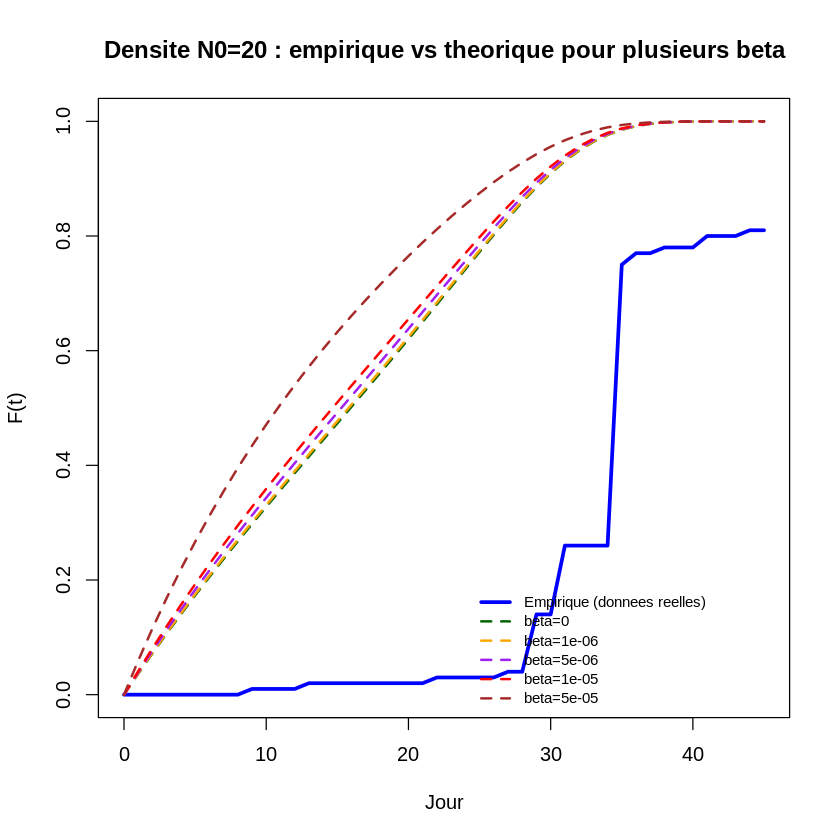

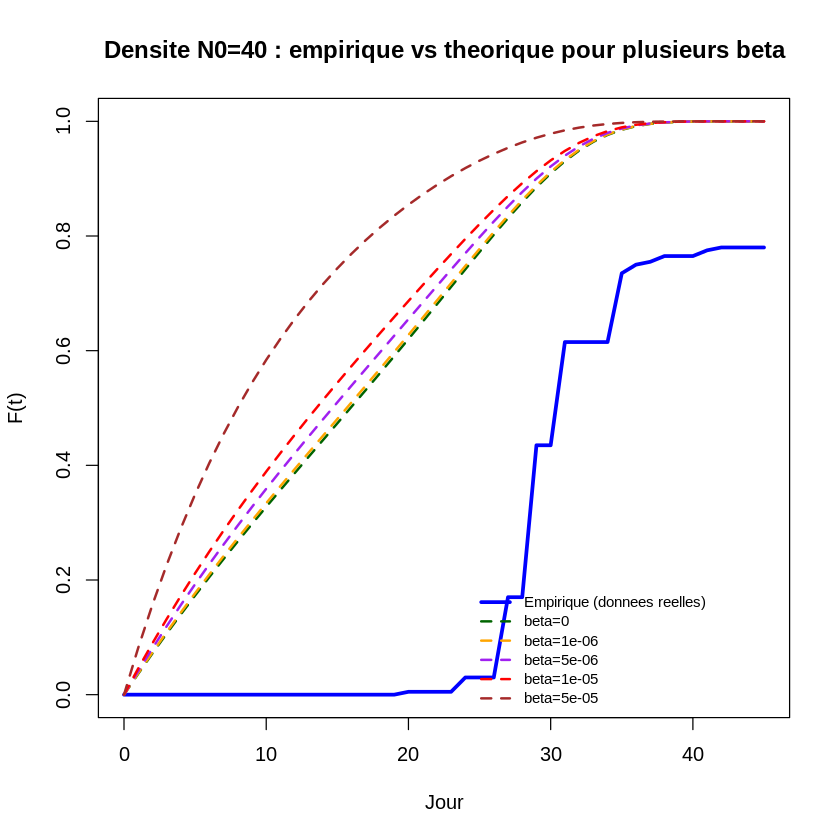

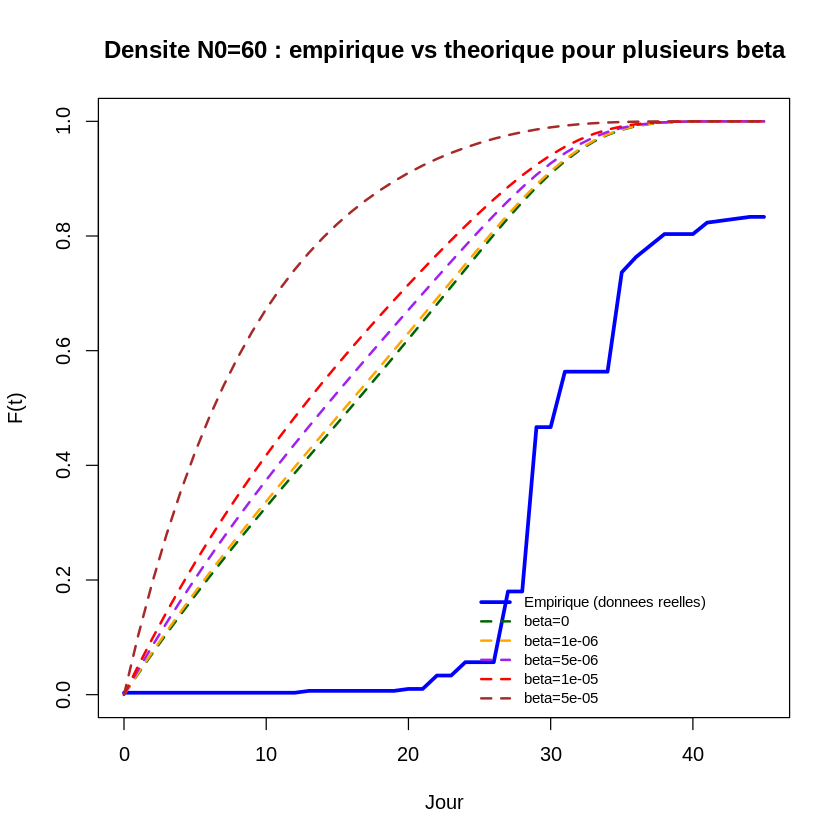

In [ ]:
#################################################################
# VERIFICATION DE LA LOI AVEC EFFET DENSITE :
# k_s(t) = F + G*exp(H*t) + beta*N0
#
# On compare, pour chaque densite (20, 40, 60), la fonction de
# repartition EMPIRIQUE (calculee a partir des vraies donnees de
# l'experience densite) a la fonction de repartition THEORIQUE pour
# PLUSIEURS valeurs candidates de beta, superposees sur le meme
# graphique -- pour voir visuellement laquelle colle le mieux.
#
# F, G, H restent FIXES aux valeurs theoriques (consigne de la prof).
#################################################################

library(readxl)


#################################################################
# 1. FONCTION DE REPARTITION THEORIQUE, AVEC EFFET DENSITE
#
# k_s(t) = F + G*exp(H*t) + beta*N0  (F,G,H,beta en heures^-1, t en heures)
# Integrale de k_s de 0 a t : F*t + (G/H)*(exp(H*t)-1) + beta*N0*t
# (le terme beta*N0 est constant en t, son integrale est donc lineaire)
#################################################################

F_NS_theo_densite <- function(t_days, F, G, H, beta, N0){
  t_h <- t_days * 24
  integrale <- F*t_h + (G/H)*(exp(H*t_h) - 1) + beta*N0*t_h
  1 - exp(-integrale)
}


#################################################################
# 2. FONCTION DE REPARTITION EMPIRIQUE, PAR DENSITE
#    (a partir des vraies donnees de densite : proportion cumulee de
#    Smurf par jour, moyennee sur les 5 tubes de chaque densite --
#    c'est exactement la fonction de repartition empirique du temps
#    de transition NS -> Smurf, tube par tube puis moyennee)
#################################################################

density_data <- read_excel("data_manip_densite_tube.xlsx", sheet = "density_data")
names(density_data)[names(density_data) == "passage smurf"] <- "passage_smurf"

calculer_empirique_densite <- function(density_data, N0_cible, grille_jours){
  tubes <- unique(density_data$ID_tube[density_data$treatment == N0_cible])
  if(length(tubes) == 0){
    cat("ATTENTION : aucun tube trouve pour N0 =", N0_cible,
        "-- verifiez que vos donnees pour cette densite sont bien chargees.\n")
    return(NULL)
  }
  courbes <- matrix(NA, nrow = length(tubes), ncol = length(grille_jours))
  for(k in seq_along(tubes)){
    sous <- density_data[density_data$ID_tube == tubes[k], ]
    sous <- sous[order(sous$day), ]
    sous <- sous[!is.na(sous$total_smurf), ]
    prop_cum <- cumsum(replace(sous$passage_smurf, is.na(sous$passage_smurf), 0)) / N0_cible
    courbes[k, ] <- approx(sous$day, prop_cum, xout = grille_jours, method = "constant", rule = 2)$y
  }
  colMeans(courbes, na.rm = TRUE)
}


#################################################################
# 3. PARAMETRES FIXES (theoriques) ET GRILLE DE TEMPS
#################################################################

F_theo <- 0.0014680557
G_theo <- 7.5447644e-05
H_theo <- 0.0066373291

grille_jours <- seq(0, 45, by = 1)

# Betas candidats a comparer visuellement (ajustez cette liste)
betas_a_tester <- c(0, 0.000001, 0.000005, 0.00001, 0.00005)
couleurs_beta <- c("darkgreen", "orange", "purple", "red", "brown")


#################################################################
# 4. GRAPHIQUE, UN PAR DENSITE : empirique vs plusieurs beta theoriques
#################################################################

tracer_verification_densite <- function(N0_cible){

  emp <- calculer_empirique_densite(density_data, N0_cible, grille_jours)

  ylim_haut <- 1
  if(is.null(emp)){
    # Pas de donnees reelles pour cette densite : on trace quand meme
    # les courbes theoriques seules, avec un titre qui le precise
    plot(NULL, xlim = range(grille_jours), ylim = c(0,1),
         xlab = "Jour", ylab = "F(t)",
         main = paste0("Densite N0=", N0_cible,
                        " : THEORIQUE SEULEMENT (pas de donnees reelles chargees)"))
  } else {
    plot(grille_jours, emp, type = "l", col = "blue", lwd = 3,
         ylim = c(0,1), xlab = "Jour", ylab = "F(t)",
         main = paste0("Densite N0=", N0_cible,
                        " : empirique vs theorique pour plusieurs beta"))
  }

  for(k in seq_along(betas_a_tester)){
    theo <- F_NS_theo_densite(grille_jours, F_theo, G_theo, H_theo,
                               betas_a_tester[k], N0_cible)
    lines(grille_jours, theo, col = couleurs_beta[k], lwd = 2, lty = 2)
  }

  if(is.null(emp)){
    legend("bottomright", legend = paste0("beta=", betas_a_tester),
           col = couleurs_beta, lty = 2, lwd = 2, bty = "n", cex = 0.75)
  } else {
    legend("bottomright",
           legend = c("Empirique (donnees reelles)",
                      paste0("beta=", betas_a_tester)),
           col = c("blue", couleurs_beta),
           lty = c(1, rep(2, length(betas_a_tester))),
           lwd = c(3, rep(2, length(betas_a_tester))),
           bty = "n", cex = 0.75)
  }
}


#################################################################
# 5. EXECUTION : un graphique par densite, affichage + sauvegarde
#################################################################

for(N0_cible in c(20, 40, 60)){
  tracer_verification_densite(N0_cible)                      # affichage inline

  png(paste0("verification_loi_densite_N0_", N0_cible, ".png"), width = 900, height = 650)
  tracer_verification_densite(N0_cible)
  dev.off()
}

Parametres moyens : F = 0.001707454  G = 7.385884e-05  H = 0.006865458  beta = 1.012394e-06 


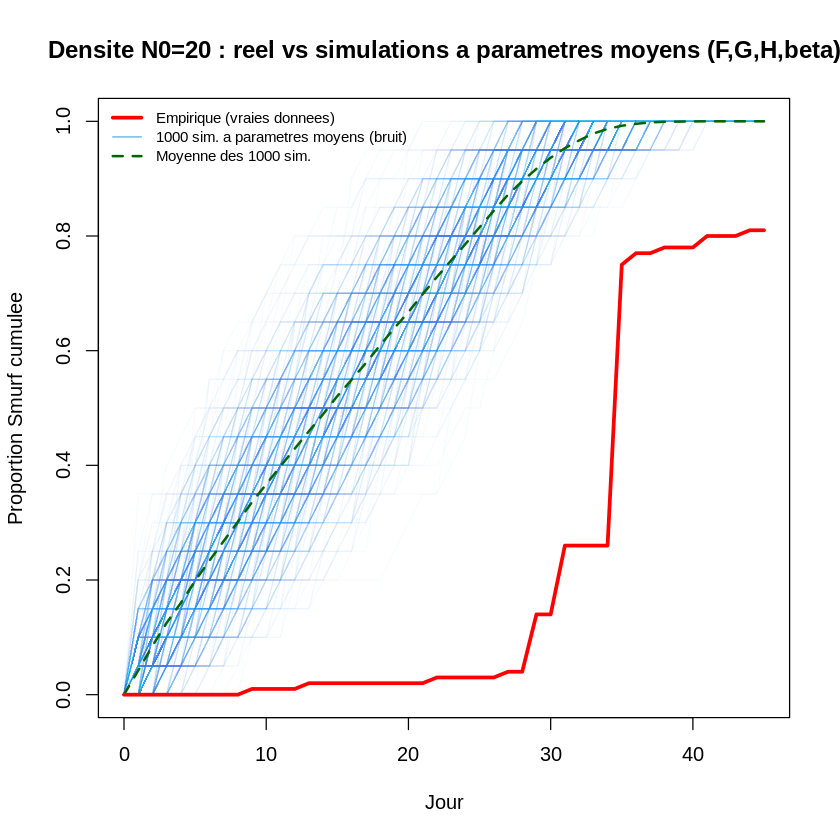

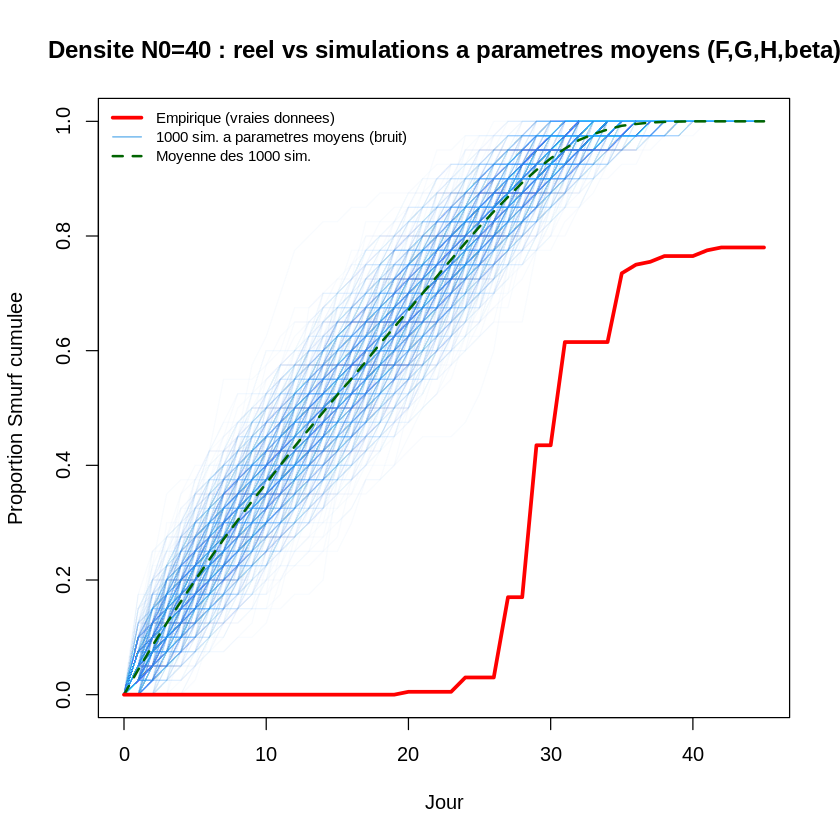


===== Comparaison numerique (jour 27, 29, 35) =====
N0= 20  jour= 27 : empirique= 0.04  simule(moyen)= 0.872 
N0= 20  jour= 29 : empirique= 0.14  simule(moyen)= 0.917 
N0= 20  jour= 35 : empirique= 0.75  simule(moyen)= 0.992 
N0= 40  jour= 27 : empirique= 0.17  simule(moyen)= 0.868 
N0= 40  jour= 29 : empirique= 0.435  simule(moyen)= 0.915 
N0= 40  jour= 35 : empirique= 0.735  simule(moyen)= 0.992 
N0= 60  jour= 27 : empirique= 0.18  simule(moyen)= 0.871 
N0= 60  jour= 29 : empirique= 0.467  simule(moyen)= 0.917 
N0= 60  jour= 35 : empirique= 0.737  simule(moyen)= 0.992 


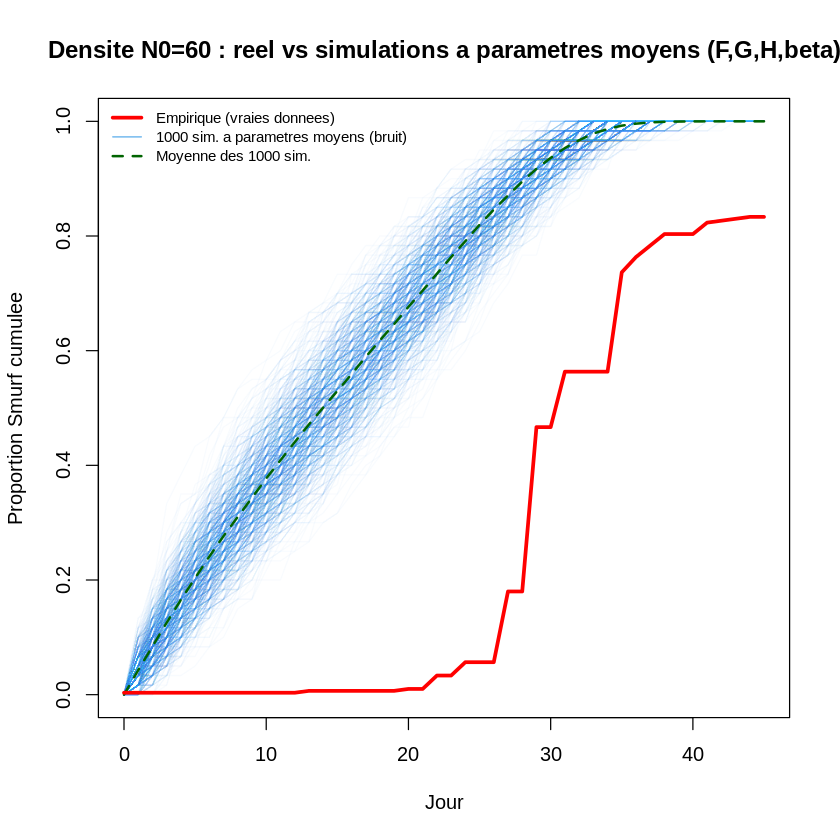

In [ ]:
#################################################################
# COMPARAISON : COURBE REELLE vs SIMULATIONS (particules F,G,H,beta)
#################################################################

#################################################################
# 1. SIMULATEUR
#################################################################

simuler_tube_contagion <- function(count_days, N0, accidental_per_period,
                                    F, G, H, beta = 0,
                                    K1, K2, D, n_substeps = 20){

  n_dates <- length(count_days)
  status <- rep("NS", N0); age <- rep(0, N0); age_smurf <- rep(NA, N0)
  out_dead_smurf   <- numeric(n_dates); out_alive_smurf  <- numeric(n_dates)
  out_total_smurf  <- numeric(n_dates); out_passage      <- numeric(n_dates)
  out_alive_female <- numeric(n_dates)
  out_alive_female[1] <- N0; out_alive_smurf[1] <- 0
  n_dead_smurf_cumul_prec <- 0

  for(i in 2:n_dates){
    t_start <- count_days[i-1]; t_end <- count_days[i]
    dt_total <- t_end - t_start; dt <- dt_total / n_substeps

    for(s in 1:n_substeps){
      t_now_h <- (t_start + (s-1)*dt) * 24
      dt_h    <- dt * 24
      idx_ns <- which(status == "NS")
      if(length(idx_ns) > 0){
        ks <- F + G*exp(H*t_now_h) + beta*N0
        ks <- pmax(ks, 0)
        prob_transition <- 1 - exp(-ks*dt_h)
        transitions <- runif(length(idx_ns)) < prob_transition
        newly_smurf <- idx_ns[transitions]
        if(length(newly_smurf) > 0){ status[newly_smurf] <- "Smurf"; age_smurf[newly_smurf] <- 0 }
      }
      idx_s <- which(status == "Smurf")
      if(length(idx_s) > 0){
        kd <- K1 + K2*exp(-D*age_smurf[idx_s]*24); kd <- pmax(kd, 0)
        prob_death <- 1 - exp(-kd*dt_h)
        deaths <- runif(length(idx_s)) < prob_death
        if(any(deaths)) status[idx_s[deaths]] <- "DeadSmurf"
      }
      age <- age + dt
      idx_s_alive <- which(status == "Smurf")
      if(length(idx_s_alive) > 0) age_smurf[idx_s_alive] <- age_smurf[idx_s_alive] + dt
    }

    n_acc <- accidental_per_period[i]
    if(!is.na(n_acc) && n_acc > 0){
      idx_alive <- which(status == "NS" | status == "Smurf")
      if(length(idx_alive) >= n_acc){
        removed <- sample(idx_alive, n_acc)
        status[removed] <- "DeadAccidental"
      }
    }

    out_alive_female[i] <- sum(status == "NS" | status == "Smurf")
    out_alive_smurf[i]  <- sum(status == "Smurf")
    n_dead_smurf_cumul <- sum(status == "DeadSmurf")
    out_dead_smurf[i] <- n_dead_smurf_cumul - n_dead_smurf_cumul_prec
    n_dead_smurf_cumul_prec <- n_dead_smurf_cumul
    out_total_smurf[i] <- out_dead_smurf[i] + out_alive_smurf[i]
    out_passage[i] <- out_total_smurf[i] - out_alive_smurf[i-1]
  }

  data.frame(day = count_days, dead_smurf = out_dead_smurf, alive_smurf = out_alive_smurf,
             total_smurf = out_total_smurf, passage_smurf = out_passage, alive_female = out_alive_female)
}


#################################################################
# 2. CHARGEMENT DES PARTICULES (F,G,H,beta) ET DES VRAIES DONNEES
#################################################################

env_particules <- new.env()
load("ABC_SMC_gen_6_FGHBeta_densité.RData", envir = env_particules)
res.new <- env_particules$res.new   # 1000 x 4 : F, G, H, beta

density_data <- read_excel("data_manip_densite_tube.xlsx", sheet = "density_data")
names(density_data)[names(density_data) == "passage smurf"] <- "passage_smurf"

grille_jours <- seq(0, 45, by = 1)

calculer_empirique_densite <- function(density_data, N0_cible, grille_jours){
  tubes <- unique(density_data$ID_tube[density_data$treatment == N0_cible])
  courbes <- matrix(NA, nrow = length(tubes), ncol = length(grille_jours))
  for(k in seq_along(tubes)){
    sous <- density_data[density_data$ID_tube == tubes[k], ]
    sous <- sous[order(sous$day), ]
    sous <- sous[!is.na(sous$total_smurf), ]
    prop_cum <- cumsum(replace(sous$passage_smurf, is.na(sous$passage_smurf), 0)) / N0_cible
    courbes[k, ] <- approx(sous$day, prop_cum, xout = grille_jours, method = "constant", rule = 2)$y
  }
  colMeans(courbes, na.rm = TRUE)
}

K1_fixe <- 0.0073127349; K2_fixe <- 0.0293175233; D_fixe <- 0.06715


#################################################################
# 3. FONCTION : simuler une courbe de proportion cumulee pour un
#    jeu de parametres (F,G,H,beta) et une densite donnee
#################################################################

simuler_courbe_proportion <- function(N0, F, G, H, beta, grille_jours){
  accidental <- rep(0, length(grille_jours)); accidental[1] <- NA
  sim <- simuler_tube_contagion(
    count_days = grille_jours, N0 = N0, accidental_per_period = accidental,
    F = F, G = G, H = H, beta = beta,
    K1 = K1_fixe, K2 = K2_fixe, D = D_fixe
  )
  cumsum(sim$passage_smurf) / N0
}


#################################################################
# 4. PARAMETRES MOYENS (des 1000 particules)
#################################################################

F_moyen <- mean(res.new[,1]); G_moyen <- mean(res.new[,2])
H_moyen <- mean(res.new[,3]); beta_moyen <- mean(res.new[,4])

cat("Parametres moyens : F =", F_moyen, " G =", G_moyen,
    " H =", H_moyen, " beta =", beta_moyen, "\n")


#################################################################
# 5. POUR CHAQUE DENSITE : empirique + 1000 (moyens)
#################################################################

n_simulations_bruit <- 1000

tracer_comparaison_densite <- function(N0_cible){

  emp <- calculer_empirique_densite(density_data, N0_cible, grille_jours)

  # 1000 simulations a parametres moyens (bruit d'echantillonnage)
  sims_bruit <- matrix(NA, nrow = n_simulations_bruit, ncol = length(grille_jours))
  for(i in 1:n_simulations_bruit){
    sims_bruit[i, ] <- simuler_courbe_proportion(N0_cible, F_moyen, G_moyen, H_moyen, beta_moyen, grille_jours)
  }
  courbe_moyenne_bruit <- colMeans(sims_bruit)

  plot(NULL, xlim = range(grille_jours), ylim = c(0,1),
       xlab = "Jour", ylab = "Proportion Smurf cumulee",
       main = paste0("Densite N0=", N0_cible,
                      " : reel vs simulations a parametres moyens (F,G,H,beta)"))

  for(i in 1:n_simulations_bruit){
    lines(grille_jours, sims_bruit[i, ], col = rgb(0.2,0.6,0.9,alpha=0.03))
  }
  lines(grille_jours, courbe_moyenne_bruit, col = "darkgreen", lwd = 2, lty = 2)
  lines(grille_jours, emp, col = "red", lwd = 3)

  legend("topleft",
         legend = c("Empirique (vraies donnees)",
                    "1000 sim. a parametres moyens (bruit)",
                    "Moyenne des 1000 sim."),
         col = c("red", rgb(0.2,0.6,0.9,alpha=0.8), "darkgreen"),
         lwd = c(3,1,2), lty = c(1,1,2), bty = "n", cex = 0.75)

  invisible(list(empirique = emp, courbe_moyenne_bruit = courbe_moyenne_bruit))
}


#################################################################
# 6. EXECUTION : un graphique par densite, affichage + sauvegarde
#################################################################

resultats_comparaison <- list()
for(N0_cible in c(20, 40, 60)){
  r <- tracer_comparaison_densite(N0_cible)
  resultats_comparaison[[as.character(N0_cible)]] <- r

  png(paste0("comparaison_reel_simule_N0_", N0_cible, ".png"), width = 900, height = 650)
  tracer_comparaison_densite(N0_cible)
  dev.off()
}

cat("\n===== Comparaison numerique (jour 27, 29, 35) =====\n")
for(N0_cible in c(20,40,60)){
  r <- resultats_comparaison[[as.character(N0_cible)]]
  for(j in c(27,29,35)){
    idx <- which(grille_jours == j)
    cat("N0=",N0_cible," jour=",j,": empirique=",round(r$empirique[idx],3),
        " simule(moyen)=",round(r$courbe_moyenne_bruit[idx],3),"\n")
  }
}

#**Simulation ABC-SMC avec des données simulées**

**Dans un `premier temps` nous allons estimer β en fixant les autres paramètres $F, G, H, K_1 , K_2 , D $.**

In [ ]:
# installation du package nécessaire pour utiliser ABC-SMC
install.packages("tmvtnorm")
library(tmvtnorm)

# 3 fonctions utilisées dans l'ABC-SMC

rK <- function(mean, sigma){
	return(rtmvnorm(1,mean=mean, sigma=sigma, lower=lm.low, upper=lm.upp))
}

H_indicator <- function(x) as.numeric(x>0)

prior.non.zero<-function(par){
	prod(sapply(1, function(a) H_indicator(par[a]-lm.low[a])* H_indicator(lm.upp[a]-par[a])))
}

In [ ]:
# Les paramètres théoriques utilies lors de la simulation

F_theo <- 0.0014680557
G_theo <- 7.5447644e-05
H_theo <- 0.0066373291
K1_fixe <- 0.0073127349
K2_fixe <- 0.0293175233
D_fixe  <- 0.06715

beta_theo <- 1e-6  # Il suffit de change en 5e-6 afin d'avoir les résultats issues de ce beta théorique
#Normalement ce beta théorique est inconue mais ici on le fixe de manière très petit tel que beta_theo* N_0
#soit plus petit que l’ordre de grandeur du taux de passage quand beta = 0


gamma_test <- 0   # effet densite COURANTE (positif = accelere quand il reste du monde)


In [ ]:
#Calcul de la distance

calc_distance_beta <- function(D_obs, params, M = 20){

  distance <- 0

  for(N0 in c(20,40,60)){

    obs <- subset(D_obs, treatment == N0)

    dist_sim <- numeric(M)

    for(m in 1:M){

      accidental <- c(NA, rep(0, nrow(obs)-1))

      sim <- simuler_tube_contagion(
        count_days = obs$day,
        N0 = N0,
        accidental_per_period = accidental,
        F = params["F"],
        G = params["G"],
        H = params["H"],
        beta = params["beta"],
        gamma = 0,
        K1 = params["K1"],
        K2 = params["K2"],
        D = params["D"]
      )

      prop_sim <- cumsum(sim$passage_smurf) / N0

      dist_sim[m] <- sum((obs$perc_smurf - prop_sim)^2)
    }

    distance <- distance + sqrt(mean(dist_sim))
  }

  return(distance)
}



In [ ]:
#Simulation pour obtenir les données théoriques


M_obs <- 5

D_obs <- data.frame()

for(N0 in c(20,40,60)){

  simulations <- matrix(NA,
                        nrow = M_obs,
                        ncol = length(count_days))

  for(m in 1:M_obs){

    accidental <- c(NA, rep(0, length(count_days)-1))

    sim <- simuler_tube_contagion(
      count_days = count_days,
      N0 = N0,
      accidental_per_period = accidental,
      F = F_theo,
      G = G_theo,
      H = H_theo,
      beta = beta_theo,
      gamma = 0,
      K1 = K1_fixe,
      K2 = K2_fixe,
      D = D_fixe
    )

    simulations[m, ] <- cumsum(sim$passage_smurf) / N0
  }

  D_obs <- rbind(
    D_obs,
    data.frame(
      treatment = N0,
      day = count_days,
      perc_smurf = colMeans(simulations)
    )
  )
}

In [ ]:
beta_ref = beta_theo

D_obs = D_obs


N = 1000 # nb de particule

epsilon_A <- c(1.8 , 1.7 , 1.5 , 1.4 , 1.2 , 1.15) # la tolérance est la même pour les deux valeurs de beta_theo


# Nb de génération
Gene <- length(epsilon_A)


# Nb de simulation pour les paramètres
n <- 1

#  borne des priors
lm.low <- c(beta = beta_ref*0.1)

lm.upp <- c(beta = beta_ref*1.9)


#simuler_populations( beta )

# Matrice vide pour stocker les paramètres
res.old<-matrix(ncol=1,nrow=N)
res.new<-matrix(ncol=1,nrow=N)

# Vecteur vide pour stocker les poids
w.old<-matrix(ncol=1,nrow=N)
w.new<-matrix(ncol=1,nrow=N)


for(g in 1:Gene){


    i<-1
    while(i <= N){ # tant que le nb de particules acceptées est inférieur à N

        if(g==1){
                # loi des distributions priors
            beta <- runif(1, min=lm.low, max=lm.upp)
        } else {
            #  selection des particules depuis la génération précédente
            p<-sample(seq(1,N),1,prob=w.old)
            par<- rK(res.old[p,],sigma)
            beta <-par[1]

        }
        #  test si le prior est nulle
        if(prior.non.zero(c( beta))) {

                m<-0
                distance <-matrix(ncol=1,nrow=n)

                for(j in 1:n){
                    params = c(F = F_theo, G =  G_theo , H = H_theo , beta = beta  , gamma = 0 , K1 =  K1_fixe , K2 = K2_fixe , D = D_fixe)

                    calc.dist<- calc_distance_beta(D_obs, params , M = 5)
                    cat("dist N= ",calc.dist , "\n")
                    distance[j,] <-calc.dist
                    if(calc.dist <= epsilon_A[g]  ){ # si les deux distances sont inferieur à leurs tolérances
                        m<-m+1
                    }
                }
                if (m>0){
                    # stockage des résultats
                    res.new[i,]<-c( beta )
                # calcul des poids
                w1 <- dunif(res.new[i,1], min = lm.low[1], max = lm.upp[1])
                if(g==1){
                    w2<-1
                } else {
                    w2<-sum(sapply(1:N, function(a) w.old[a]* dtmvnorm(res.new[i,], mean=res.old[a,], sigma=sigma, lower=lm.low, upper=lm.upp)))
                }
                w.new[i] <- (m/n)*w1/w2
                i <- i+1
                print(paste0('Generation: ', g, ", particle: ", i))
                }
            }
        }

        sigma <- cov(res.new)
        res.old<-res.new
    w.old<-w.new/sum(w.new)
}
colnames(res.new) = c("beta")
res.new <- as.data.frame(res.new)

**`Deux méthodes` : soit vous resimuler le code ci-dessus avant de lancer les codes pour l'analyse des paramètres acceptés, soit vous importer et charger (load("Nom_du_fichier.Rdata)) le fichier data associé à sa distance qui se trouve dans le Github**

**Analysons les paramètres acceptés et traçons leur histogramme**

In [ ]:
#Analyse des paramètres

estimated_beta = res.new[,1]

mean_beta = mean(estimated_beta)





interv_credible_beta = quantile(estimated_beta, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de beta

cat("Pour le paramètre beta :\n")
cat("  Moyenne des estimations :", round(mean_beta, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_beta), 15), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_beta[1], 6), ", ", round(interv_credible_beta[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_beta[2], 6) - round(interv_credible_beta[1], 6), "\n")



In [ ]:
# ==================================================
# HISTOGRAMMES DES PARAMETRES ACCEPTES
# ==================================================

# Taille des figures
options(
  repr.plot.width = 16,
  repr.plot.height = 12
)




  # Résultats du cas 1
  res <- res.new



  # =================================================
  # HISTOGRAMME F
  # =================================================

  hist(
    res$beta,
    breaks = 20,
    probability = TRUE,
    col = "lightblue",
    main = paste("beta"),
    xlab = expression(beta),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.000015)
  )




**Dans un `deuxième temps` nous allons estimer $F, G, H, β$ en fixant les autres paramètres $K_1 , K_2 , D $, la formule de distance reste la même.**

In [ ]:
#Rappel

F_theo <- 0.0014680557
G_theo <- 7.5447644e-05
H_theo <- 0.0066373291
K1_fixe <- 0.0073127349
K2_fixe <- 0.0293175233
D_fixe  <- 0.06715
beta_theo <- 1e-6 # ici ce beta_theo est fixé
gamma_test <- 0   # effet densite COURANTE (positif = accelere quand il reste du monde)


In [ ]:
#Calcul de la distance

calc_distance_beta <- function(D_obs, params, M = 20){

  distance <- 0

  for(N0 in c(20,40,60)){

    obs <- subset(D_obs, treatment == N0)

    dist_sim <- numeric(M)

    for(m in 1:M){

      accidental <- c(NA, rep(0, nrow(obs)-1))

      sim <- simuler_tube_contagion(
        count_days = obs$day,
        N0 = N0,
        accidental_per_period = accidental,
        F = params["F"],
        G = params["G"],
        H = params["H"],
        beta = params["beta"],
        gamma = 0,
        K1 = params["K1"],
        K2 = params["K2"],
        D = params["D"]
      )

      prop_sim <- cumsum(sim$passage_smurf) / N0

      dist_sim[m] <- sum((obs$perc_smurf - prop_sim)^2)
    }

    distance <- distance + sqrt(mean(dist_sim))
  }

  return(distance)
}



In [ ]:
#Simulation pour obtenir les données théoriques


M_obs <- 5

D_obs <- data.frame()

for(N0 in c(20,40,60)){

  simulations <- matrix(NA,
                        nrow = M_obs,
                        ncol = length(count_days))

  for(m in 1:M_obs){

    accidental <- c(NA, rep(0, length(count_days)-1))

    sim <- simuler_tube_contagion(
      count_days = count_days,
      N0 = N0,
      accidental_per_period = accidental,
      F = F_theo,
      G = G_theo,
      H = H_theo,
      beta = beta_theo,
      gamma = 0,
      K1 = K1_fixe,
      K2 = K2_fixe,
      D = D_fixe
    )

    simulations[m, ] <- cumsum(sim$passage_smurf) / N0
  }

  D_obs <- rbind(
    D_obs,
    data.frame(
      treatment = N0,
      day = count_days,
      perc_smurf = colMeans(simulations)
    )
  )
}

In [ ]:
beta_ref = beta_theo

D_obs = D_obs



N = 1000 # nb de particule

epsilon_A <- c(4 , 3.7 , 3.2 , 2.7 , 2.2 , 1.7)


# Nb de génération
Gene <- length(epsilon_A)


# Nb de simulation pour les paramètres
n <- 1

#  borne des priors
lm.low <- c(
  F=F_theo*0.1 ,
  G=G_theo*0.1,
  H=H_theo*0.1,
  beta = beta_ref*0.1
)
lm.upp <- c(
  F=F_theo*1.9 ,
  G=G_theo*1.9,
  H=H_theo*1.9,
  beta = beta_ref*1.9
)




#simuler_populations( beta )

# Matrice vide pour stocker les paramètres
res.old<-matrix(ncol=4,nrow=N)
res.new<-matrix(ncol=4,nrow=N)

# Vecteur vide pour stocker les poids
w.old<-matrix(ncol=1,nrow=N)
w.new<-matrix(ncol=1,nrow=N)


for(g in 1:Gene){


    i<-1
    while(i <= N){ # tant que le nb de particules acceptées est inférieur à N

        if(g==1){
                # loi des distributions priors
            F <- runif(1, min=lm.low[1], max=lm.upp[1])
            G <-runif(1, min=lm.low[2], max=lm.upp[2])
            H <-runif(1, min=lm.low[3], max=lm.upp[3])
            beta <-runif(1, min=lm.low[4], max=lm.upp[4])

        } else {
            #  selection des particules depuis la génération précédente
            p<-sample(seq(1,N),1,prob=w.old)
            par<- rK(res.old[p,],sigma)
            F <-par[1]
            G <- par[2]
            H <-par[3]
            beta <-par[4]

        }
        #  test si le prior est nulle
        if(prior.non.zero(c( F,G,H ,beta))) {

                m<-0
                distance <-matrix(ncol=1,nrow=n)

                for(j in 1:n){
                    params = c(F = F, G =  G , H = H , beta = beta  , gamma = 0 , K1 =  K1_fixe , K2 = K2_fixe , D = D_fixe)

                    calc.dist<- calc_distance_beta(D_obs, params , M = 5)
                    cat("dist N= ",calc.dist , "\n")
                    distance[j,] <-calc.dist
                    if(calc.dist <= epsilon_A[g]  ){ # si les deux distances sont inferieur à leurs tolérances
                        m<-m+1
                    }
                }
                if (m>0){
                    # stockage des résultats
                    res.new[i,]<-c( F,G,H,beta )
                # calcul des poids
                w1<-prod(sapply(1:4, function(b) dunif(res.new[i,b], min=lm.low[b], max=lm.upp[b])))  # à modifier de comment on calcul le poids
                if(g==1){
                    w2<-1
                } else {
                    w2<-sum(sapply(1:N, function(a) w.old[a]* dtmvnorm(res.new[i,], mean=res.old[a,], sigma=sigma, lower=lm.low, upper=lm.upp)))
                }
                w.new[i] <- (m/n)*w1/w2
                i <- i+1
                print(paste0('Generation: ', g, ", particle: ", i))
                }
            }
        }

        sigma <- cov(res.new)
        res.old<-res.new
    w.old<-w.new/sum(w.new)
}
colnames(res.new) = c("F" , "G" , "H" , "beta")
res.new <- as.data.frame(res.new)

**`Deux méthodes` : soit vous resimuler le code ci-dessus avant de lancer les codes pour l'analyse des paramètres acceptés, soit vous importer et charger (load("Nom_du_fichier.Rdata)) le fichier data associé à sa distance qui se trouve dans le Github**

**Analysons les paramètres acceptés et traçons leur histogramme**

In [ ]:
estimated_F = res.new[,1]
estimated_G = res.new[,2]
estimated_H = res.new[,3]
estimated_beta = res.new[,4]


mean_F = mean(estimated_F)
mean_G = mean(estimated_G)
mean_H = mean(estimated_H)
mean_beta = mean(estimated_beta)


interv_credible_F = quantile(estimated_F, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de F
interv_credible_G = quantile(estimated_G, c(0.025,0.975))   #un intervalle de crédibilité à 95 %  de G
interv_credible_H = quantile(estimated_H, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de H
interv_credible_beta = quantile(estimated_beta, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de beta

cat("Pour le paramètre F :\n")
cat("  Moyenne des estimations :", round(mean_F, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_F), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_F[1], 6), ", ", round(interv_credible_F[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_F[2], 6) - round(interv_credible_F[1], 6), "\n")

cat("Pour le paramètre G :\n")
cat("  Moyenne des estimations :", round(mean_G, 9), "\n")
cat("  Variance des estimations :", round(var(estimated_G), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_G[1], 6), ", ", round(interv_credible_G[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_G[2], 6) - round(interv_credible_G[1], 6), "\n")

cat("Pour le paramètre H :\n")
cat("  Moyenne des estimations :", round(mean_H, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_H), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_H[1], 6), ", ", round(interv_credible_H[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_H[2], 6) - round(interv_credible_H[1], 6), "\n")

cat("Pour le paramètre beta :\n")
cat("  Moyenne des estimations :", round(mean_beta, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_beta), 15), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_beta[1], 6), ", ", round(interv_credible_beta[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_beta[2], 6) - round(interv_credible_beta[1], 6), "\n")

In [ ]:
# ==================================================
# HISTOGRAMMES DES PARAMETRES ACCEPTES
# ==================================================

# Taille des figures
options(
  repr.plot.width = 16,
  repr.plot.height = 12
)




  # Résultats du cas 1
  res <- res.new


# =================================================
  # HISTOGRAMME F
  # =================================================

  hist(
    res$F,
    breaks = 20,
    probability = TRUE,
    col = "lightblue",
    main = paste("F "),
    xlab = expression(F),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.004)
  )

  abline(
    v = 0.00146805570484498,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME G
  # =================================================

  hist(
    res$G,
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "G  "),
    xlab = expression(G),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.0002)
  )

  abline(
    v = 7.54476439893396e-05 ,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME H
  # =================================================

  hist(
    res$H,
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "H  " ),
    xlab = expression(H),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.015)
  )

  abline(
    v = 0.0066373291015625 ,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME beta
  # =================================================

  hist(
    res$beta,
    breaks = 20,
    probability = TRUE,
    col = "lightblue",
    main = paste("beta"),
    xlab = expression(beta),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.0000025)
  )
 abline(
    v = 1e-6 ,
    col = "red",
    lwd = 2,
    lty = 2
  )

